In [57]:
import pandas as pd
import matplotlib.pyplot as mplt
import seaborn as sn
from sqlalchemy import create_engine

#username = "postgres"
#password = ""
#host = "localhost" 
#port = "5432"
#database = "Weather and Energy Database"

engine = create_engine("postgresql+psycopg2://postgres:@localhost:5432/Weather and Energy Database")

In [58]:
weather_df = pd.read_sql("SELECT * FROM history_weather_data;", con=engine) # read the weather data currently in the sql database 
demand_df = pd.read_sql("SELECT * FROM energy_demand_data;", con=engine) # read the energy data currently in the sql database

demand_df = demand_df.drop(columns=["FORECAST_ACTUAL_INDICATOR", "SCOTTISH_TRANSFER"], errors="ignore")

print(demand_df.index.is_monotonic_increasing)

True


In [59]:

print(demand_df.duplicated(subset=["datetime"]).sum())
print(weather_df.duplicated(subset=["datetime"]).sum())

weather_df = weather_df.set_index("datetime")
demand_df = demand_df.set_index("datetime")

print(demand_df.columns)
print(demand_df.index.name)
print(weather_df.index.name)

print(demand_df.index.is_monotonic_increasing)
demand_df = demand_df.sort_index()

12
0
Index(['SETTLEMENT_DATE', 'SETTLEMENT_PERIOD', 'ND', 'TSD',
       'ENGLAND_WALES_DEMAND', 'EMBEDDED_WIND_GENERATION',
       'EMBEDDED_WIND_CAPACITY', 'EMBEDDED_SOLAR_GENERATION',
       'EMBEDDED_SOLAR_CAPACITY', 'NON_BM_STOR', 'PUMP_STORAGE_PUMPING',
       'IFA_FLOW', 'IFA2_FLOW', 'BRITNED_FLOW', 'MOYLE_FLOW', 'EAST_WEST_FLOW',
       'NEMO_FLOW', 'NSL_FLOW', 'ELECLINK_FLOW', 'VIKING_FLOW',
       'GREENLINK_FLOW'],
      dtype='str')
datetime
datetime
False


In [79]:

def date_filter (df, start_date, end_date):
    return df.loc[start_date:end_date]

filtered_wdf = date_filter(weather_df, start_date = "2023-02-01", end_date = "2023-02-28")
filtered_ddf = date_filter(demand_df, start_date = "2023-02-01", end_date = "2023-02-28")

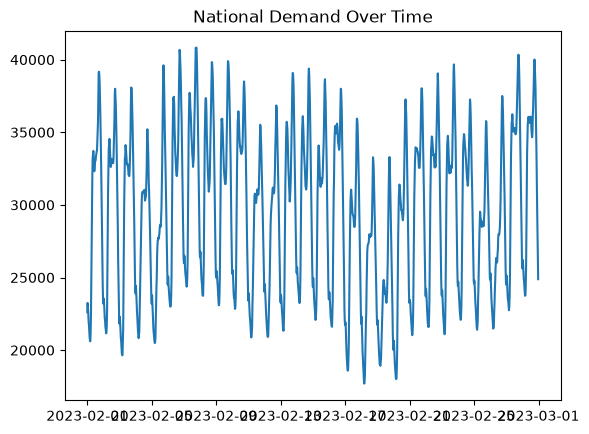

In [82]:
demand_df_hourly = demand_df[demand_df.index.minute == 0]
mplt.plot(filtered_ddf.index, filtered_ddf["ND"])
mplt.title("National Demand Over Time")
mplt.show()

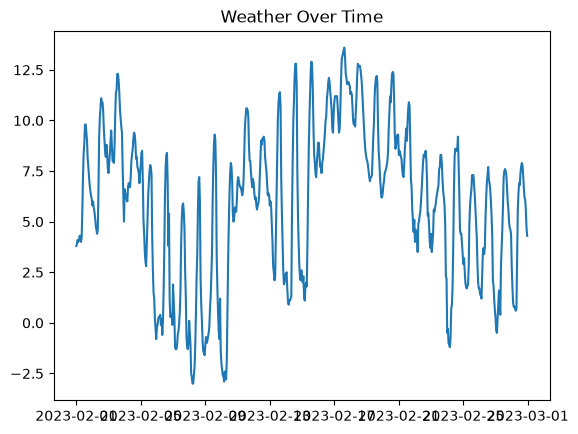

In [81]:

mplt.plot(filtered_wdf.index, filtered_wdf["temperature_2m"])
mplt.title("Weather Over Time")
mplt.show()